In [18]:
#description: this inputs the csv from uno, dos, or tres, and the csv with the clicker data, and makes cuts. 
    #first cut: drop all events in the first and last 10 seconds of both csvs
    #second cut: create windows of events and background and graph the voltage during a train event and/or the background

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define pds
voltagedata = pd.read_csv('./output/stationTest.CSV')
voltagedata['voltage'] = voltagedata['sensor'] * (5 / 16383)

# assume the input csv file has events and a time associated with the event NOT including the hours (i.e. instead of 22:47:39.5 the csv will have 47:39.5 in seconds)
clickerdata = pd.read_csv('./output/platform_run.csv')

# remove first and last 10 seconds
time_min = voltagedata['seconds'].min()
time_max = voltagedata['seconds'].max()

voltagedata = voltagedata[
    (voltagedata['seconds'] >= time_min + 10) &
    (voltagedata['seconds'] <= time_max - 10)
].reset_index(drop=True)

# remove these from the clicker data as well
time_min_c = clickerdata['seconds'].min()
time_max_c = clickerdata['seconds'].max()

clickerdata = clickerdata[
    (clickerdata['seconds'] >= time_min_c + 10) &
    (clickerdata['seconds'] <= time_max_c - 10)
].reset_index(drop=True)

In [3]:
# parameters for when we create windows
window_half_width = 100
use_exact_match = False
max_time_diff = 0.1

voltagedata['seconds'] = pd.to_numeric(voltagedata['seconds'], errors='coerce')
clickerdata['seconds'] = pd.to_numeric(clickerdata['seconds'], errors='coerce')

In [4]:
#drop rowss
voltagedropped = voltagedata.dropna(subset=['seconds']).reset_index(drop=True)
clickerdropped = clickerdata.dropna(subset=['seconds']).reset_index(drop=True)

In [5]:
# neither of the csvs start their events at t = 0
# shift both files so first event starts at t = 0
t0_voltage = voltagedropped['seconds'].iloc[0]
t0_clicker = clickerdropped['seconds'].iloc[0]

voltagedropped['seconds'] = voltagedropped['seconds'] - t0_voltage
clickerdropped['seconds'] = clickerdropped['seconds'] - t0_clicker

# convert to numpy arrays
voltagetimes = voltagedropped['seconds'].to_numpy()
clickertimes = clickerdropped['seconds'].to_numpy()

print(f"voltage csv first time was {t0_voltage}, now starts at {voltagetimes[0]}")
print(f"clicker csv first time was {t0_clicker}, now starts at {clickertimes[0]}")

voltage csv first time was 81760.0, now starts at 0.0
clicker csv first time was 2585.3, now starts at 0.0


In [6]:
# identify events in both csvs that occur at the same time
# find indices that are in both csvs
matching = []
if use_exact_match:
    precision = 3
    timeindices = {}

    for i, t in enumerate(voltagetimes):
        t_round = round(t, precision)
        timeindices.setdefault(t_round, []).append(i)

    for t in clickertimes:
        t_round = round(t, precision)
        if t_round in timeindices:
            matching.extend(timeindices[t_round])

else:
    for t in clickertimes:
        index = np.argmin(np.abs(voltagetimes - t))
        diff = abs(voltagetimes[index] - t)

        if diff <= max_time_diff:
            matching.append(index)

# remove duplicates + sort
matching = sorted(set(matching))

print(f'Number of events that occur at the same time in both csvs: {len(matching)}')
print(f'Matched Indices: {matching}')

Number of events that occur at the same time in both csvs: 14
Matched Indices: [np.int64(0), np.int64(525), np.int64(944), np.int64(1086), np.int64(1623), np.int64(1931), np.int64(3895), np.int64(4999), np.int64(5089), np.int64(5535), np.int64(6778), np.int64(9266), np.int64(9537), np.int64(9661)]


In [7]:
# build windows around each event identified above
# for now the windows include 50 events around each such event - change the paramater in the second cell to change this
windows = []
indexranges = []

for index in matching:
    startindex = max(0, index - window_half_width)
    endindex = min(len(voltagetimes) - 1, index + window_half_width)

    windowdf = voltagedropped.iloc[startindex:endindex + 1].copy().reset_index(drop=True)
    windows.append(windowdf)
    indexranges.append((startindex, endindex))

print(f'Created {len(windows)} windows.')

Created 14 windows.


In [8]:
# create set of arrays, each one representing a window (16 total)
windowArr = [w.to_numpy() for w in windows]
#windowArr[0]
#windowArr[1]
#windowArr[2]
#windowArr[3]
#windowArr[4]
#windowArr[5]
#windowArr[6]
#windowArr[7]
#windowArr[8]
#windowArr[9]
#windowArr[10]
#windowArr[11]
#windowArr[12]
#windowArr[13]
#windowArr[14]
#windowArr[15]

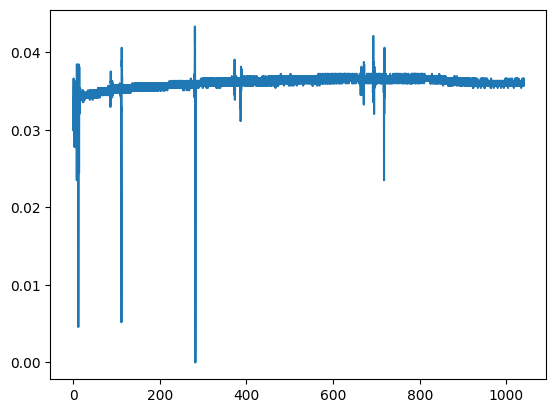

In [9]:
plt.plot(voltagedropped['seconds'], voltagedropped['voltage'])

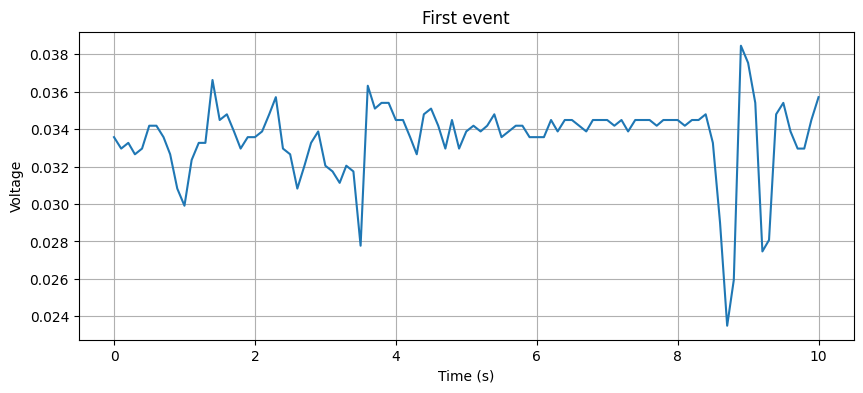

In [10]:
w0 = windows[0]

plt.figure(figsize=(10,4))
plt.plot(w0['seconds'], w0['voltage'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('First event')
plt.grid(True)
plt.show()

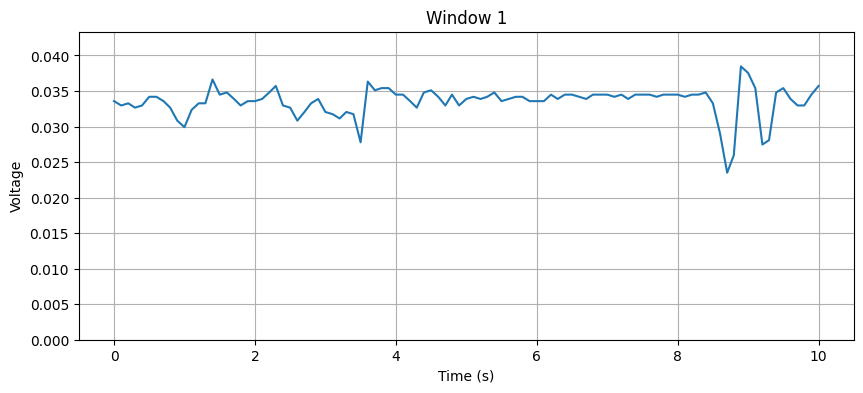

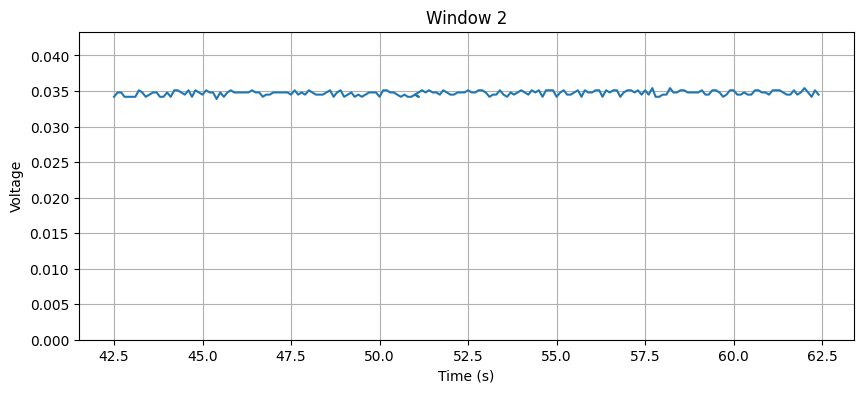

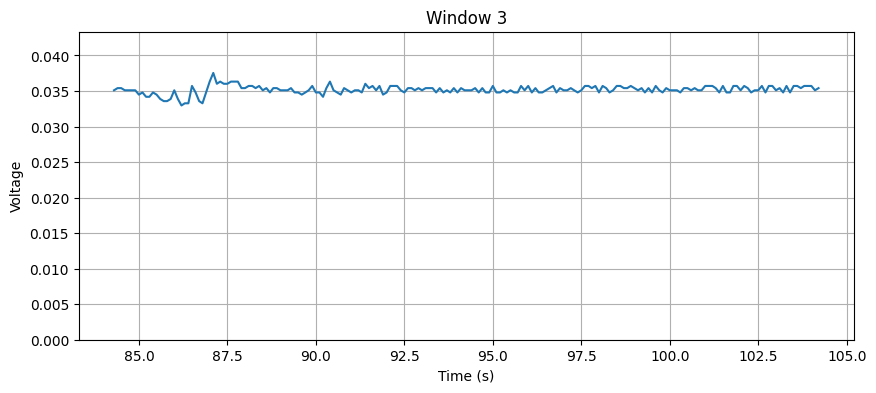

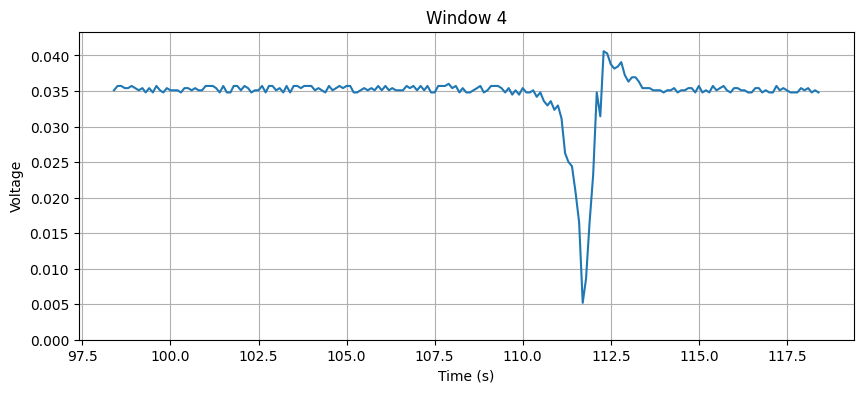

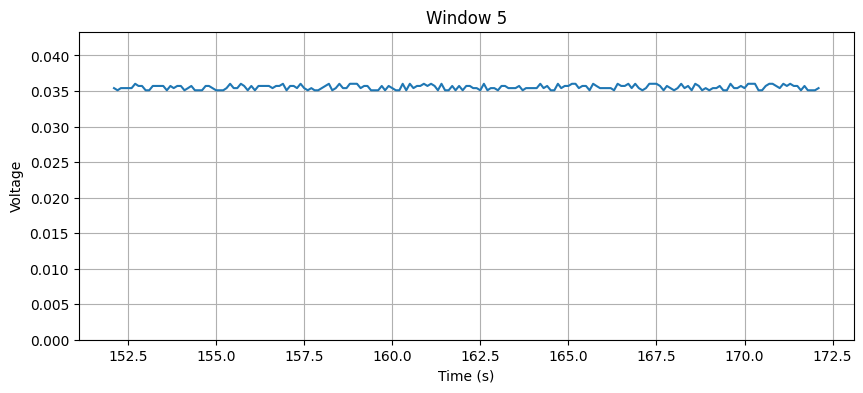

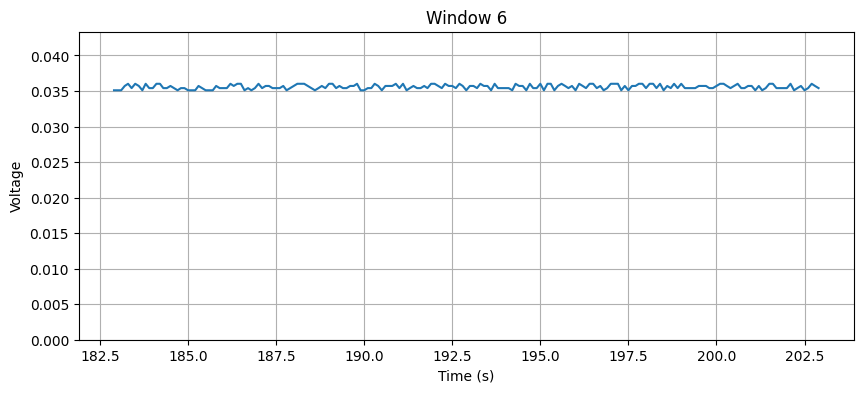

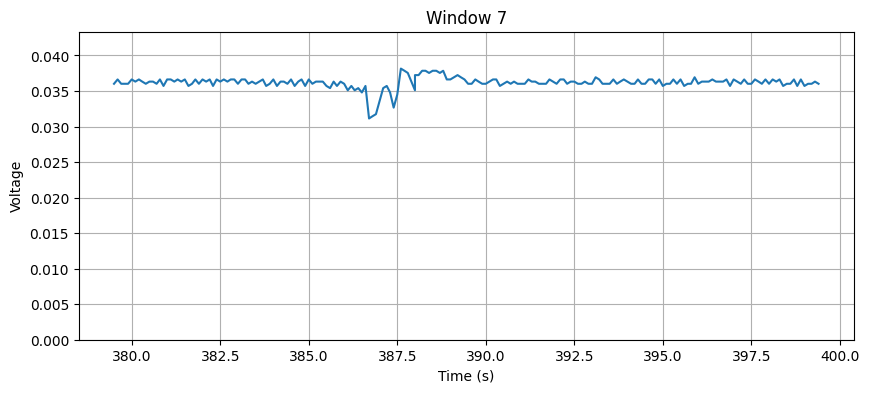

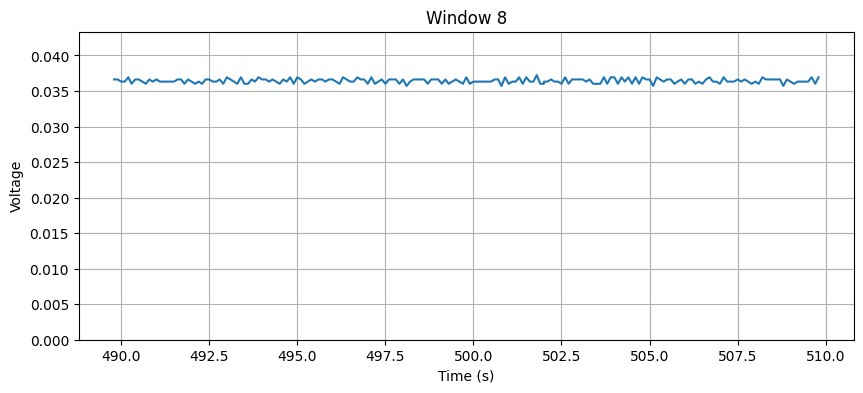

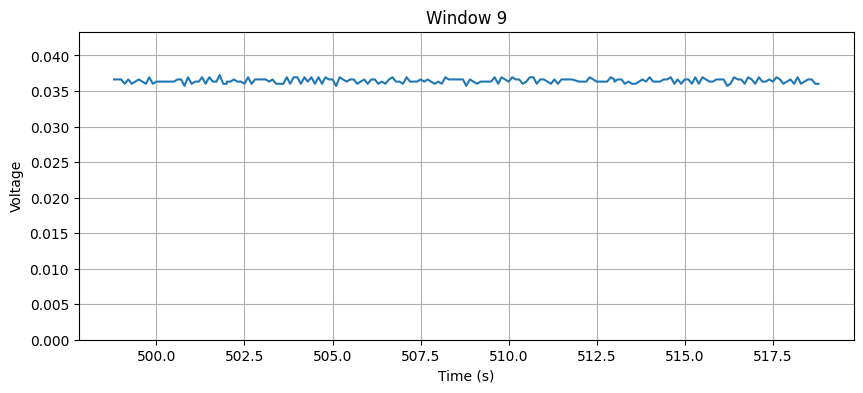

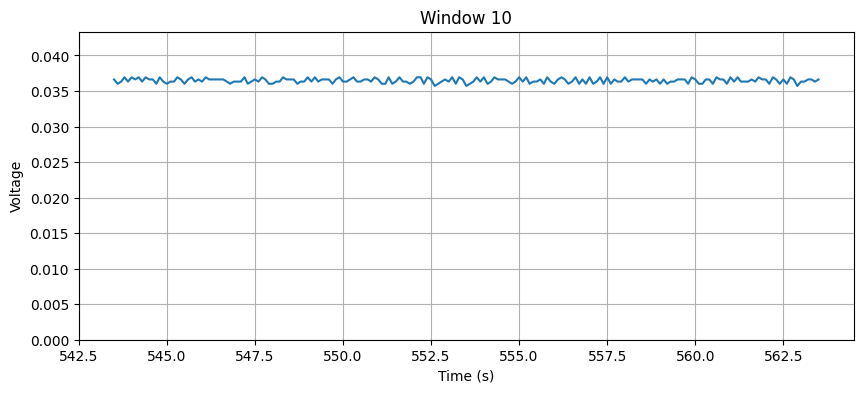

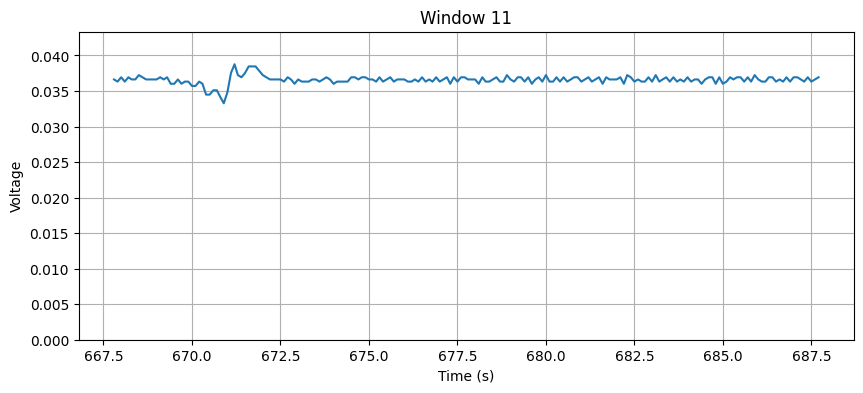

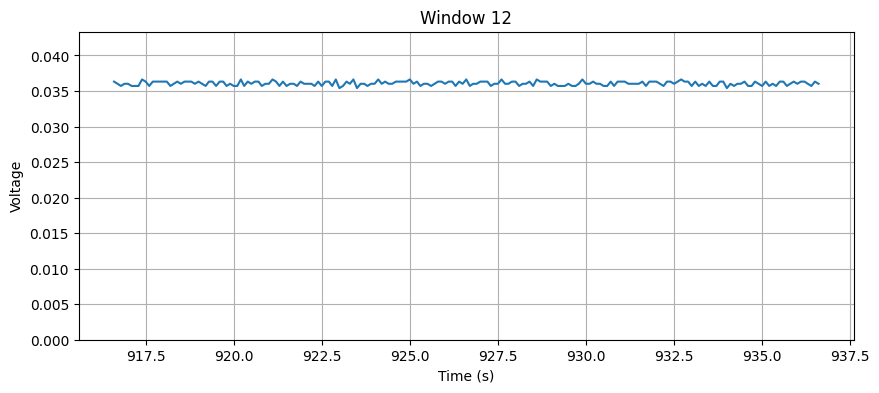

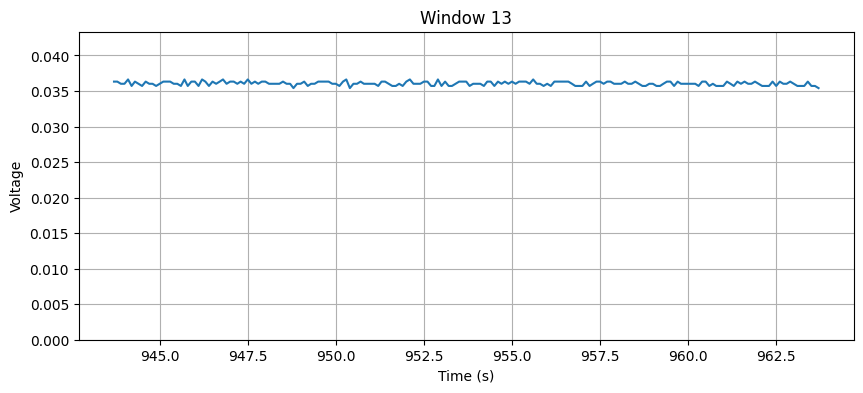

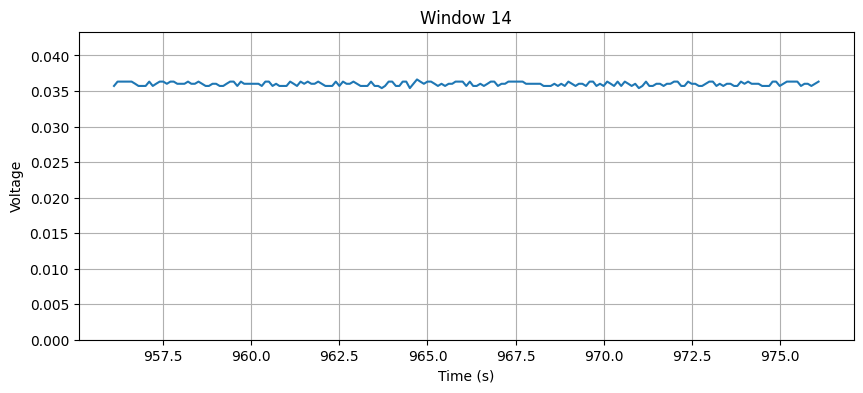

In [11]:
#check what happens when we do vs don't impose a global ymin and ymax

global_ymin = voltagedropped['voltage'].min()
global_ymax = voltagedropped['voltage'].max()

for i, w in enumerate(windows):
    plt.figure(figsize=(10,4))
    plt.plot(w['seconds'], w['voltage'])
    plt.ylim(global_ymin, global_ymax)
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage')
    plt.title(f'Window {i+1}')
    plt.grid(True)
    plt.show()

In [12]:
mergedranges = []

if len(indexranges) > 0:
    sortedranges = sorted(indexranges)
    currentstart, currentend = sortedranges[0]

    for start, end in sortedranges[1:]:
        if start <= currentend + 1:
            currentend = max(currentend, end)
        else:
            mergedranges.append((currentstart, currentend))
            currentstart, currentend = start, end
    mergedranges.append((currentstart, currentend))

print('Merged ranges:', mergedranges)

Merged ranges: [(0, np.int64(100)), (np.int64(425), np.int64(625)), (np.int64(844), np.int64(1186)), (np.int64(1523), np.int64(1723)), (np.int64(1831), np.int64(2031)), (np.int64(3795), np.int64(3995)), (np.int64(4899), np.int64(5189)), (np.int64(5435), np.int64(5635)), (np.int64(6678), np.int64(6878)), (np.int64(9166), np.int64(9366)), (np.int64(9437), np.int64(9761))]


In [13]:
# do the same thing, but each window is the time between when a train passed

backgroundwindows = []

if len(mergedranges) == 0:
    backgroundwindows.append(voltagedropped.copy().reset_index(drop=True))

else:
    firststart = mergedranges[0][0]
    if firststart > 0:
        bg = voltagedropped.iloc[:firststart].copy().reset_index(drop=True)
        backgroundwindows.append(bg)

    for i in range(len(mergedranges) - 1):
        prevend = mergedranges[i][1]
        nextstart = mergedranges[i + 1][0]

        if nextstart > prevend + 1:
            bg = voltagedropped.iloc[prevend + 1:nextstart].copy().reset_index(drop=True)
            backgroundwindows.append(bg)

    lastend = mergedranges[-1][1]
    if lastend < len(voltagedropped) - 1:
        bg = voltagedropped.iloc[lastend + 1:].copy().reset_index(drop=True)
        backgroundwindows.append(bg)

print(f'Created {len(backgroundwindows)} background windows.')

Created 11 background windows.


In [14]:
for i, bg in enumerate(backgroundwindows):
    print(f'Background window {i+1}: {len(bg)} events')

Background window 1: 324 events
Background window 2: 218 events
Background window 3: 336 events
Background window 4: 107 events
Background window 5: 1763 events
Background window 6: 903 events
Background window 7: 245 events
Background window 8: 1042 events
Background window 9: 2287 events
Background window 10: 70 events
Background window 11: 643 events


In [15]:
backgroundArr = [bg.to_numpy() for bg in backgroundwindows]
backgroundArr[0]

array([['260407_224250_100', 10.101999999998952, 4200.0581, ..., 'W',
        117, 0.03570774583409632],
       ['260407_224250_200', 10.202999999994063, 4200.0581, ..., 'W',
        114, 0.03479216260758103],
       ['260407_224250_300', 10.297000000005937, 4200.0581, ..., 'W',
        114, 0.03479216260758103],
       ...,
       ['260407_224322_200', 42.20299999999406, 4200.0566, ..., 'W', 112,
        0.03418177378990417],
       ['260407_224322_300', 42.29700000000594, 4200.0566, ..., 'W', 115,
        0.03509735701641946],
       ['260407_224322_400', 42.39800000000105, 4200.0566, ..., 'W', 115,
        0.03509735701641946]], shape=(324, 8), dtype=object)

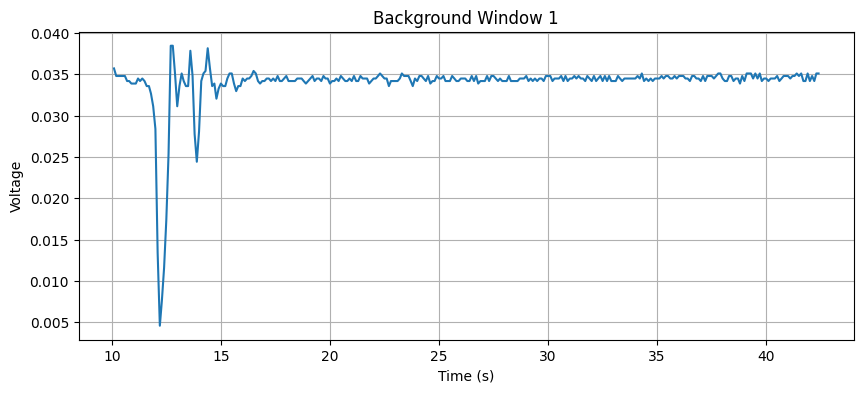

In [16]:
bg0 = backgroundwindows[0]

plt.figure(figsize=(10,4))
plt.plot(bg0['seconds'], bg0['voltage'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage')
plt.title('Background Window 1')
plt.grid(True)
plt.show()

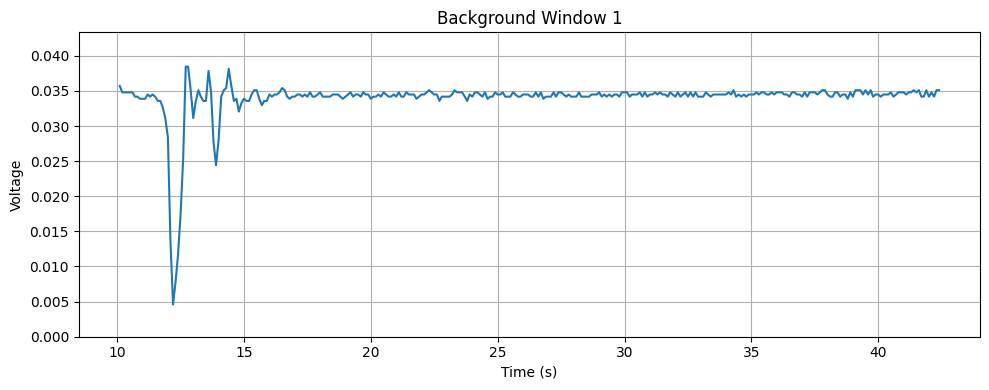

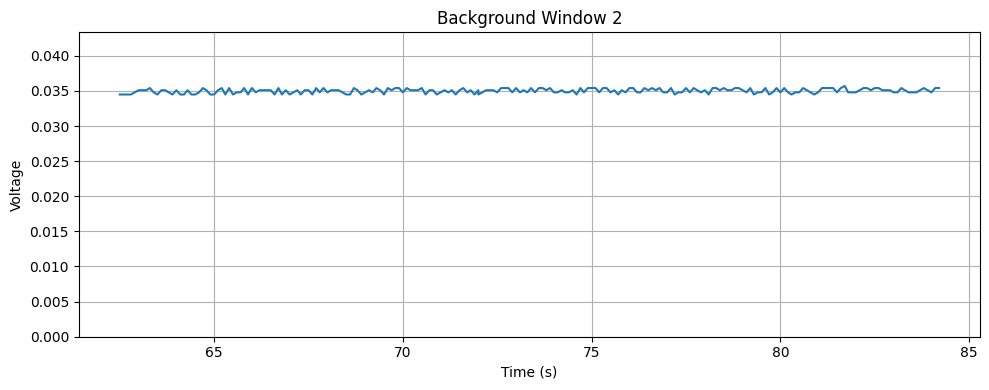

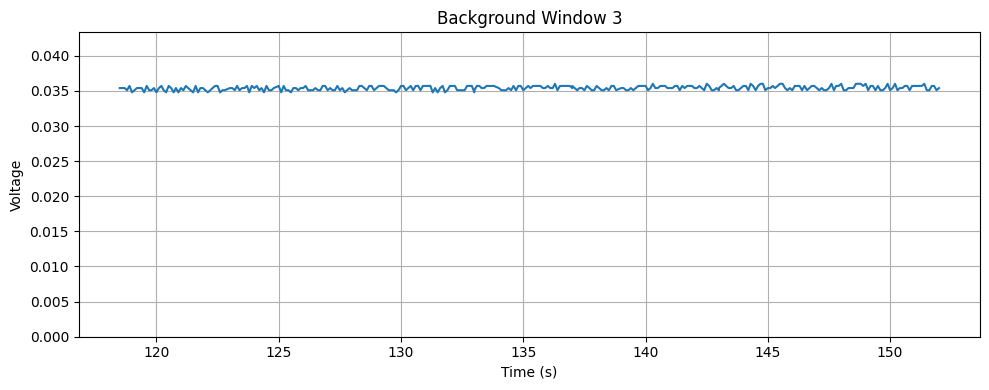

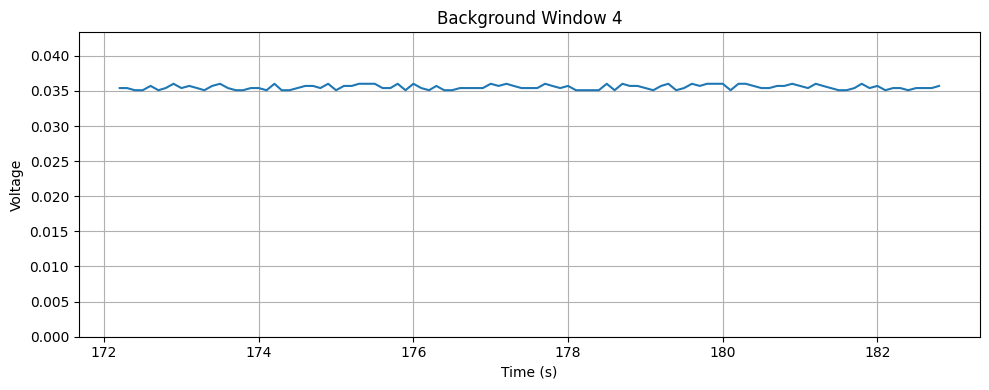

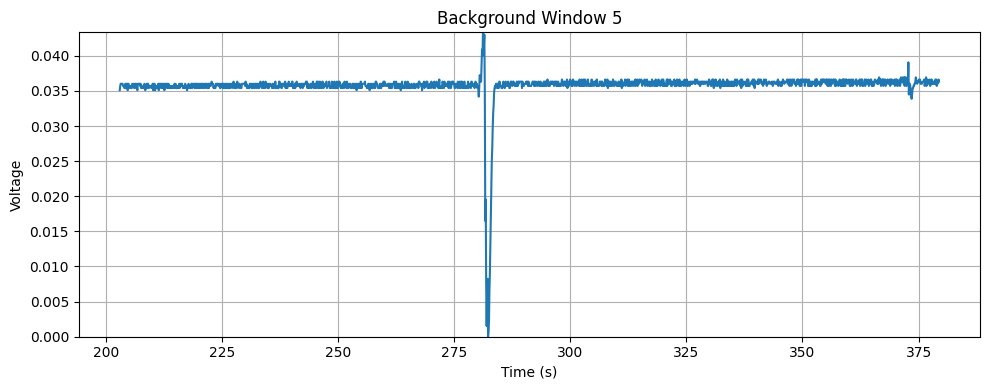

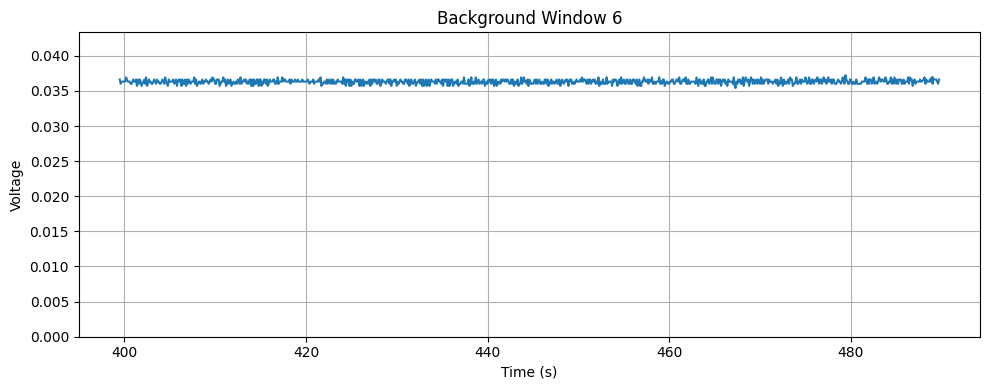

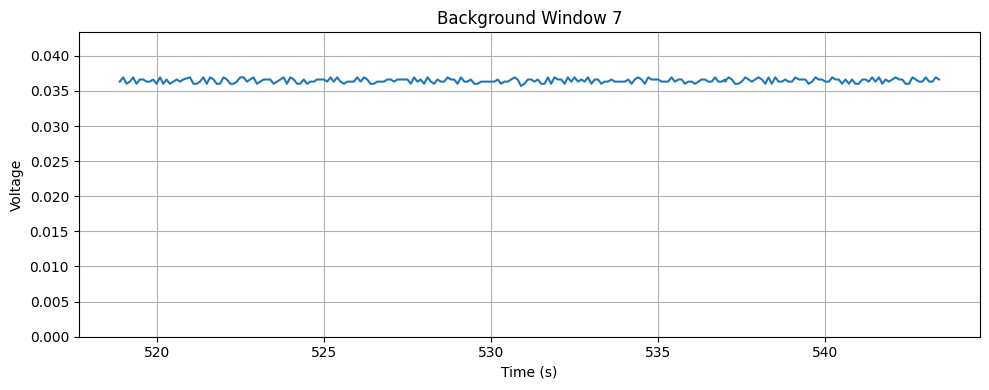

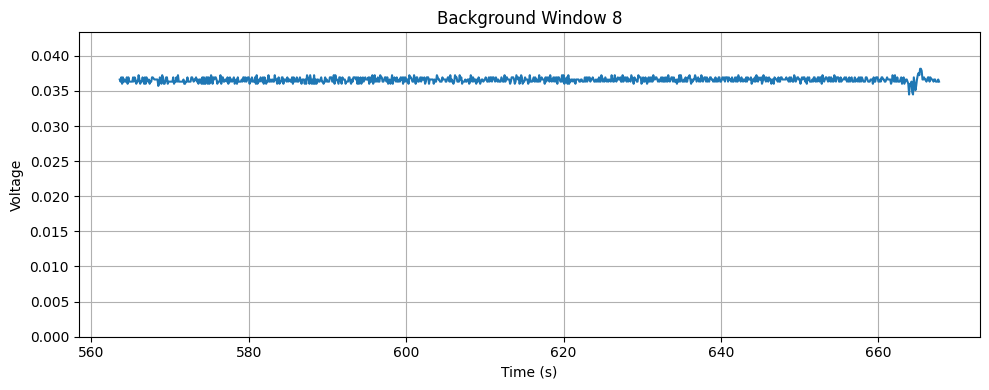

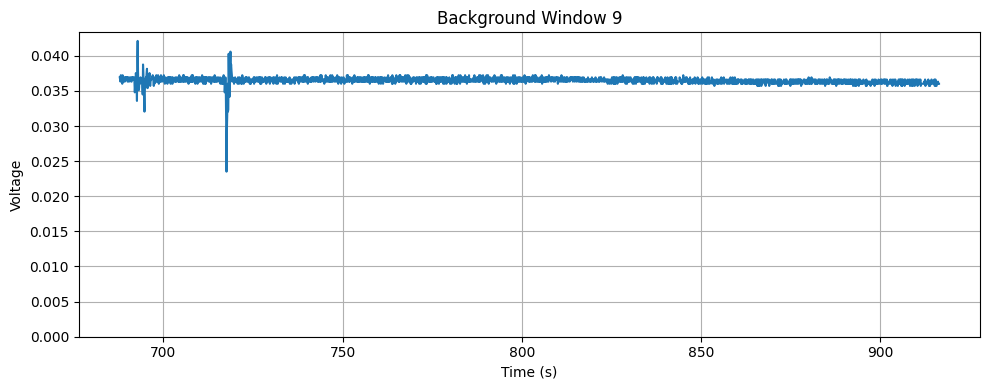

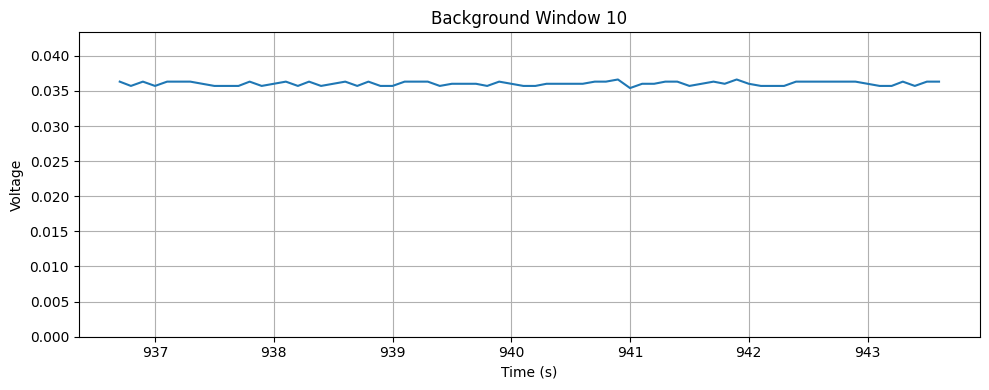

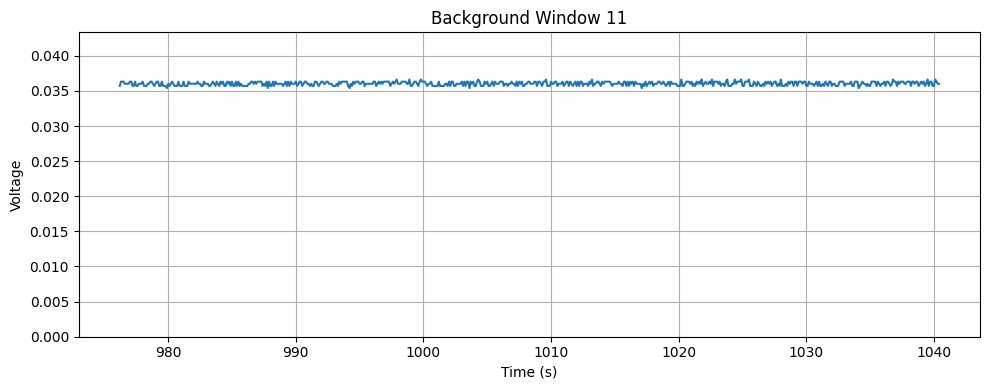

In [17]:
for i, bg in enumerate(backgroundwindows):
    plt.figure(figsize=(10,4))
    plt.plot(bg['seconds'], bg['voltage'])
    plt.ylim(global_ymin, global_ymax)
    plt.xlabel('Time (s)')
    plt.ylabel('Voltage')
    plt.title(f'Background Window {i+1}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()